In [1]:
# CELL 1 — Imports + GPU Setup

import os
import torch
import torch.nn as nn
import timm

import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import datasets

from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

from collections import Counter

# ─────────────────────────────────────────────
# DEVICE / GPU SETUP
# ─────────────────────────────────────────────

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 50)
print("PYTORCH / DEVICE INFORMATION")
print("=" * 50)

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"Device          : {device}")

if torch.cuda.is_available():
    print(f"GPU name        : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version    : {torch.version.cuda}")
    print(
        f"GPU memory      : "
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )
else:
    print("⚠️ CUDA GPU not available.")
    print("Training will fall back to CPU.")

print("=" * 50)

PYTORCH / DEVICE INFORMATION
PyTorch version : 2.0.1+cu118
CUDA available  : True
Device          : cuda
GPU name        : NVIDIA GeForce RTX 3050 Laptop GPU
CUDA version    : 11.8
GPU memory      : 4.00 GB


In [4]:
# CELL 2 — Configuration

from pathlib import Path

# Repo root: walk up from the notebook's directory until app.py is found.
BASE_PATH = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "app.py").is_file())
DATA_DIR = BASE_PATH / "datasets" / "KAGGLE DATASET" / "Combined Dataset" / "train"
MODELS_PATH = BASE_PATH / "models"
RESULTS_PATH = BASE_PATH / "results"

MODEL_NAME = "efficientnet_b4"
NUM_CLASSES = 4
IMG_SIZE = 380
BATCH_SIZE = 16
NUM_WORKERS = 4
EPOCHS = 20

os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

print(f"Dataset path : {DATA_DIR}")
print(f"Models path  : {MODELS_PATH}")
print(f"Results path : {RESULTS_PATH}")
print(f"Model        : {MODEL_NAME}")
print(f"Image size   : {IMG_SIZE}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Epochs       : {EPOCHS}")

Dataset path : datasets\KAGGLE DATASET\Combined Dataset\train
Models path  : models
Results path : results
Model        : efficientnet_b4
Image size   : 380
Batch size   : 16
Epochs       : 20


In [5]:
# CELL 3 — Dataset and DataLoaders

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

base_dataset = datasets.ImageFolder(DATA_DIR)

class_names = base_dataset.classes
class_to_idx = base_dataset.class_to_idx
samples = base_dataset.samples

total = len(samples)
train_size = int(0.70 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

generator = torch.Generator().manual_seed(42)
indices = torch.randperm(total, generator=generator).tolist()

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

train_dataset = datasets.ImageFolder(
    DATA_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    DATA_DIR,
    transform=val_transform
)

test_dataset = datasets.ImageFolder(
    DATA_DIR,
    transform=val_transform
)

train_data = torch.utils.data.Subset(train_dataset, train_indices)
val_data = torch.utils.data.Subset(val_dataset, val_indices)
test_data = torch.utils.data.Subset(test_dataset, test_indices)

pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=NUM_WORKERS > 0
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=NUM_WORKERS > 0
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=NUM_WORKERS > 0
)

print(f"Classes: {class_names}")
print(f"Class mapping: {class_to_idx}")
print(f"Total images: {total}")
print(f"Train images: {len(train_data)}")
print(f"Validation images: {len(val_data)}")
print(f"Test images: {len(test_data)}")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Classes: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']
Class mapping: {'Mild Impairment': 0, 'Moderate Impairment': 1, 'No Impairment': 2, 'Very Mild Impairment': 3}
Total images: 10240
Train images: 7168
Validation images: 1536
Test images: 1536
Train batches: 448
Validation batches: 96
Test batches: 96


In [6]:
# CELL 4 — Class Distribution and Weights

train_labels = [samples[i][1] for i in train_indices]

class_counts = Counter(train_labels)
total_train = len(train_labels)

class_weights = []

for class_idx in range(NUM_CLASSES):
    count = class_counts.get(class_idx, 0)
    weight = total_train / (NUM_CLASSES * count)
    class_weights.append(weight)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

print("Training class distribution:")

for class_idx, class_name in enumerate(class_names):
    count = class_counts.get(class_idx, 0)
    percentage = 100 * count / total_train
    print(f"{class_name}: {count} ({percentage:.2f}%)")

print("\nClass weights:")

for class_idx, weight in enumerate(class_weights):
    print(f"{class_names[class_idx]}: {weight.item():.4f}")

Training class distribution:
Mild Impairment: 1793 (25.01%)
Moderate Impairment: 1800 (25.11%)
No Impairment: 1791 (24.99%)
Very Mild Impairment: 1784 (24.89%)

Class weights:
Mild Impairment: 0.9994
Moderate Impairment: 0.9956
No Impairment: 1.0006
Very Mild Impairment: 1.0045


In [7]:
# CELL 5 — Build EfficientNet-B4

UNFREEZE_MARKERS = [
    "blocks.5",
    "blocks.6",
    "conv_head",
    "classifier",
    "bn2"
]

def freeze_bn_stats(model):
    for name, module in model.named_modules():
        if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            if not any(marker in name for marker in UNFREEZE_MARKERS):
                module.eval()
                module.weight.requires_grad = False
                module.bias.requires_grad = False

def build_efficientnet():
    model = timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=NUM_CLASSES
    )

    for name, param in model.named_parameters():
        param.requires_grad = any(
            marker in name for marker in UNFREEZE_MARKERS
        )

    freeze_bn_stats(model)

    return model

eff_model = build_efficientnet()

total_params = sum(
    p.numel() for p in eff_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in eff_model.parameters()
    if p.requires_grad
)

print(f"Model: {MODEL_NAME}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

Model: efficientnet_b4
Total parameters: 17,555,788
Trainable parameters: 13,942,076
Frozen parameters: 3,613,712


In [8]:
# CELL 6 — GPU Forward-Pass Test

eff_model = eff_model.to(device)

images, labels = next(iter(train_loader))

images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

with torch.cuda.amp.autocast():
    outputs = eff_model(images)

print(f"Input shape: {images.shape}")
print(f"Output shape: {outputs.shape}")
print(f"Device: {images.device}")
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

del images, labels, outputs

torch.cuda.empty_cache()

Input shape: torch.Size([16, 3, 380, 380])
Output shape: torch.Size([16, 4])
Device: cuda:0
GPU memory allocated: 4.65 GB
GPU memory reserved: 4.88 GB


In [9]:
# CELL 7 — Adjust batch size for GPU memory

BATCH_SIZE = 8

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0
)

print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Batch size: 8
Train batches: 896
Validation batches: 192
Test batches: 192


In [10]:
# CELL 8 — Training Function

from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

def set_bn_eval(model):
    for name, module in model.named_modules():
        if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            if not any(marker in name for marker in UNFREEZE_MARKERS):
                module.eval()

def train_and_save(model, epochs=20):
    model = model.to(device)

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=0.001
    )

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=7,
        gamma=0.1
    )

    best_val_acc = 0.0
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        model.train()
        set_bn_eval(model)

        correct = 0
        total = 0
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * labels.size(0)

            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        train_loss = running_loss / total

        model.eval()

        correct = 0
        total = 0
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                with autocast():
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                val_loss += loss.item() * labels.size(0)

                _, preds = outputs.max(1)
                correct += preds.eq(labels).sum().item()
                total += labels.size(0)

        val_acc = 100 * correct / total
        val_loss = val_loss / total

        scheduler.step()

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc

            torch.save(
                model.state_dict(),
                os.path.join(
                    MODELS_PATH,
                    f"{MODEL_NAME}_best.pth"
                )
            )

            saved = "Saved"
        else:
            saved = ""

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.2f}% | "
            f"LR: {current_lr:.6f} {saved}"
        )

    return model, train_accs, val_accs, best_val_acc

In [11]:
# CELL 9 — Train Model

eff_model = build_efficientnet()

eff_model, train_accs, val_accs, best_acc = train_and_save(
    model=eff_model,
    epochs=EPOCHS
)

print(f"\nBest validation accuracy: {best_acc:.2f}%")

Epoch 1/20 | Train Loss: 0.6031 | Train Acc: 73.65% | Val Loss: 0.3912 | Val Acc: 81.45% | LR: 0.001000 Saved
Epoch 2/20 | Train Loss: 0.3982 | Train Acc: 82.38% | Val Loss: 0.3325 | Val Acc: 86.20% | LR: 0.001000 Saved
Epoch 3/20 | Train Loss: 0.3168 | Train Acc: 86.77% | Val Loss: 0.3753 | Val Acc: 85.48% | LR: 0.001000 
Epoch 4/20 | Train Loss: 0.2405 | Train Acc: 90.62% | Val Loss: 0.2122 | Val Acc: 91.47% | LR: 0.001000 Saved
Epoch 5/20 | Train Loss: 0.1851 | Train Acc: 92.90% | Val Loss: 0.2758 | Val Acc: 91.02% | LR: 0.001000 
Epoch 6/20 | Train Loss: 0.1479 | Train Acc: 94.29% | Val Loss: 0.1688 | Val Acc: 94.60% | LR: 0.001000 Saved
Epoch 7/20 | Train Loss: 0.1120 | Train Acc: 96.11% | Val Loss: 0.1739 | Val Acc: 93.82% | LR: 0.000100 
Epoch 8/20 | Train Loss: 0.0454 | Train Acc: 98.54% | Val Loss: 0.0791 | Val Acc: 96.88% | LR: 0.000100 Saved
Epoch 9/20 | Train Loss: 0.0258 | Train Acc: 99.14% | Val Loss: 0.0821 | Val Acc: 97.33% | LR: 0.000100 Saved
Epoch 10/20 | Train Loss:

In [12]:
# CELL 10 — Load Best Model

best_model_path = os.path.join(
    MODELS_PATH,
    f"{MODEL_NAME}_best.pth"
)

eff_model = build_efficientnet()

eff_model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

eff_model = eff_model.to(device)
eff_model.eval()

print(f"Loaded: {best_model_path}")
print(f"Device: {device}")

Loaded: models\efficientnet_b4_best.pth
Device: cuda


In [13]:
# CELL 11 — Test Evaluation

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)

        with autocast():
            outputs = eff_model(images)

        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(
    all_labels,
    all_preds
) * 100

print(f"Test Accuracy: {test_acc:.2f}%\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    )
)

Test Accuracy: 98.11%

                      precision    recall  f1-score   support

     Mild Impairment     0.9947    0.9843    0.9895       382
 Moderate Impairment     1.0000    1.0000    1.0000       377
       No Impairment     0.9593    0.9767    0.9679       386
Very Mild Impairment     0.9716    0.9642    0.9679       391

            accuracy                         0.9811      1536
           macro avg     0.9814    0.9813    0.9813      1536
        weighted avg     0.9812    0.9811    0.9811      1536



Confusion Matrix:
[[376   0   3   3]
 [  0 377   0   0]
 [  1   0 377   8]
 [  1   0  13 377]]


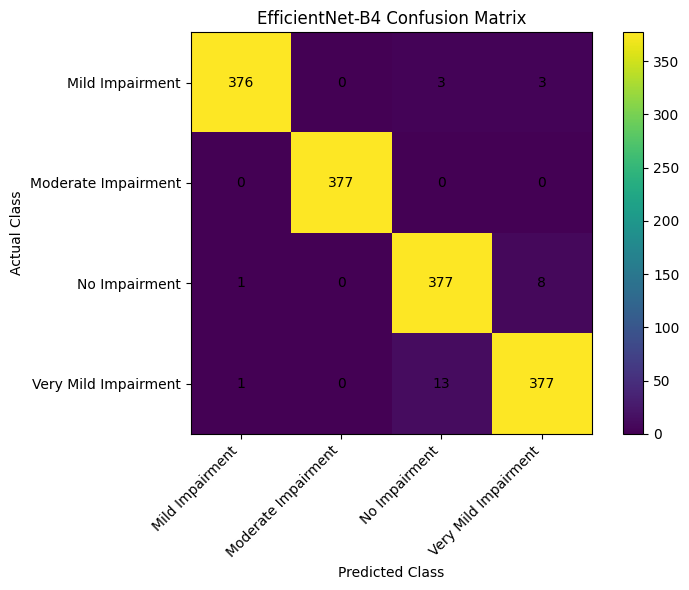

In [14]:
# CELL 12 — Confusion Matrix

cm = confusion_matrix(
    all_labels,
    all_preds
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))

plt.imshow(cm, interpolation="nearest")
plt.title("EfficientNet-B4 Confusion Matrix")
plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_CLASSES),
    class_names
)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

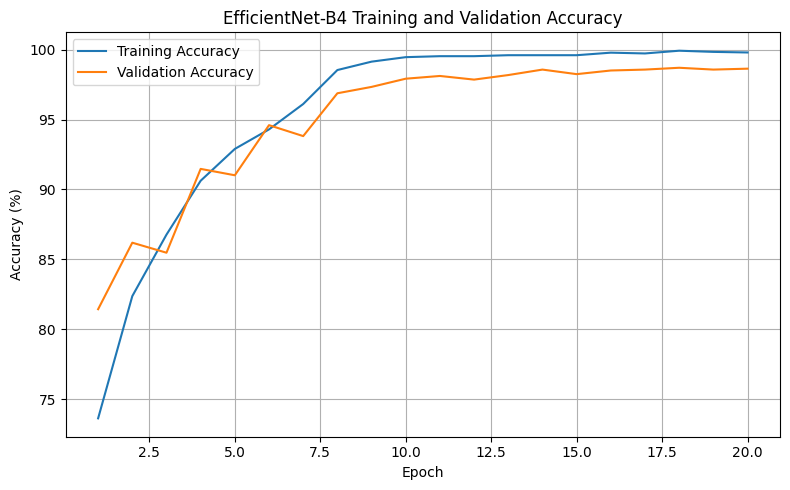

In [15]:
# CELL 13 — Training Curves

epochs_range = range(1, len(train_accs) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_accs,
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_accs,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("EfficientNet-B4 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# CELL 14 — Save Model Information

import json

model_info = {
    "model_name": MODEL_NAME,
    "num_classes": NUM_CLASSES,
    "img_size": IMG_SIZE,
    "class_names": class_names,
    "class_to_idx": class_to_idx,
    "best_validation_accuracy": best_acc,
    "test_accuracy": test_acc
}

info_path = os.path.join(
    MODELS_PATH,
    f"{MODEL_NAME}_info.json"
)

with open(info_path, "w") as f:
    json.dump(model_info, f, indent=4)

print(f"Model checkpoint: {best_model_path}")
print(f"Model information: {info_path}")
print(f"Best validation accuracy: {best_acc:.2f}%")
print(f"Test accuracy: {test_acc:.2f}%")

Model checkpoint: models\efficientnet_b4_best.pth
Model information: models\efficientnet_b4_info.json
Best validation accuracy: 98.70%
Test accuracy: 98.11%


In [17]:
# CELL 15 — Single Image Prediction

from PIL import Image

def predict_image(image_path, model):
    image = Image.open(image_path).convert("L")

    image = val_transform(image).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        with autocast():
            outputs = model(image)

        probabilities = torch.softmax(outputs, dim=1)
        confidence, prediction = probabilities.max(1)

    predicted_class = class_names[prediction.item()]
    confidence = confidence.item() * 100

    print(f"Predicted class: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")

    return predicted_class, confidence

In [19]:
# CELL 16 — Test Image

test_sample = test_data.indices[0]

image_path, true_label = test_dataset.samples[test_sample]

true_class = class_names[true_label]

print(f"Image: {image_path}")
print(f"Actual class: {true_class}")

predicted_class, confidence = predict_image(
    image_path,
    eff_model
)

Image: datasets\KAGGLE DATASET\Combined Dataset\train\Moderate Impairment\ModerateImpairment (544).jpg
Actual class: Moderate Impairment
Predicted class: Moderate Impairment
Confidence: 100.00%


In [20]:
# CELL 17 — Test One Image Per Class

for class_idx, class_name in enumerate(class_names):
    class_indices = [
        i for i in test_data.indices
        if test_dataset.samples[i][1] == class_idx
    ]

    sample_idx = class_indices[0]
    image_path, true_label = test_dataset.samples[sample_idx]

    predicted_class, confidence = predict_image(
        image_path,
        eff_model
    )

    print(f"Actual: {class_name}")
    print(f"Predicted: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")
    print()

Predicted class: Mild Impairment
Confidence: 100.00%
Actual: Mild Impairment
Predicted: Mild Impairment
Confidence: 100.00%

Predicted class: Moderate Impairment
Confidence: 100.00%
Actual: Moderate Impairment
Predicted: Moderate Impairment
Confidence: 100.00%

Predicted class: No Impairment
Confidence: 100.00%
Actual: No Impairment
Predicted: No Impairment
Confidence: 100.00%

Predicted class: Very Mild Impairment
Confidence: 100.00%
Actual: Very Mild Impairment
Predicted: Very Mild Impairment
Confidence: 100.00%



In [21]:
# CELL 18 — Visual Prediction

def show_prediction(image_path, model):
    image = Image.open(image_path).convert("L")

    input_tensor = val_transform(image).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        with autocast():
            outputs = model(input_tensor)

        probabilities = torch.softmax(outputs, dim=1)[0]

    prediction = probabilities.argmax().item()
    predicted_class = class_names[prediction]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"Predicted: {predicted_class}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.barh(class_names, probabilities.cpu().numpy() * 100)
    plt.xlabel("Probability (%)")
    plt.title("Class Probabilities")

    plt.tight_layout()
    plt.show()

    print(f"Predicted class: {predicted_class}")
    print(f"Confidence: {probabilities[prediction].item() * 100:.2f}%")
    print("\nClass probabilities:")

    for name, probability in zip(
        class_names,
        probabilities.cpu().numpy()
    ):
        print(f"{name}: {probability * 100:.2f}%")

Image: datasets\KAGGLE DATASET\Combined Dataset\train\Moderate Impairment\ModerateImpairment (544).jpg


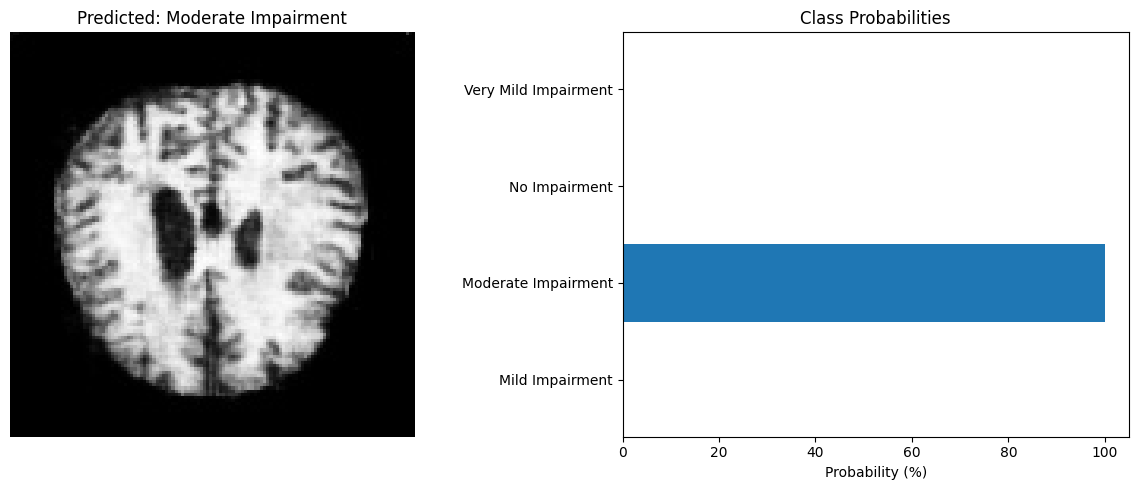

Predicted class: Moderate Impairment
Confidence: 100.00%

Class probabilities:
Mild Impairment: 0.00%
Moderate Impairment: 100.00%
No Impairment: 0.00%
Very Mild Impairment: 0.00%


In [22]:
# CELL 19 — Run Visual Prediction

image_path = test_dataset.samples[
    test_data.indices[0]
][0]

print(f"Image: {image_path}")

show_prediction(
    image_path,
    eff_model
)